### Imports

In [ ]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
os.chdir("MASK/Documents/Anuja")
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
import networkx as nx
from matplotlib.font_manager import fontManager, FontProperties

# 1. Probe Analysis - English

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models
model_language = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_language.pth", local_files_only=True).to(device)
model_semantic = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_semantic.pth", local_files_only=True).to(device)
model_whole = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en.pth", local_files_only=True).to(device)
model_base = AutoModel.from_pretrained("bert-base-uncased").to(device)  # Base BERT

# Use the same tokenizer for all (base BERT- This should be correct but I may need to ask it to Anuja)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)


In [3]:
analyzer = StructuralProbeAnalyzer(
    [model_base, model_whole, model_semantic, model_language],
    [tokenizer] * 4,  # same tokenizer for all
    device=device
)


Before diving into, let's analyze how different the weights are (this part has been added after the second meeting, after the discussion that we had about the similarity of the weights). Transformers have many layer types, here specifically I focused on the embedding layers (token/position embeddings) and the attention layers (Self-Attention Blocks).

In [4]:
df_compare = analyzer.compare_to_base_attention_embedding_combined(
    model_names=["BERT-base","BERT-whole","BERT-semantic","BERT-language"]
)
df_compare

,Comparison,Layer,Type,Max_Diff,Mean_Diff
0,BERT-whole vs BERT-base,Embedding,Embedding,0.0002,0.000010
1,BERT-whole vs BERT-base,0,QKV_combined,0.0002,0.000143
2,BERT-whole vs BERT-base,1,QKV_combined,0.0002,0.000144
3,BERT-whole vs BERT-base,2,QKV_combined,0.0002,0.000142
4,BERT-whole vs BERT-base,3,QKV_combined,0.0002,0.000143
5,BERT-whole vs BERT-base,4,QKV_combined,0.0002,0.000142
6,BERT-whole vs BERT-base,5,QKV_combined,0.0002,0.000140
7,BERT-whole vs BERT-base,6,QKV_combined,0.0002,0.000141
8,BERT-whole vs BERT-base,7,QKV_combined,0.0002,0.000139
9,BERT-whole vs BERT-base,8,QKV_combined,0.0002,0.000140


In [5]:
weight_df = analyzer.analyze_model_weights(model_names=["BERT-base","BERT-whole","BERT-semantic","BERT-language"])

Base model 'BERT-base' has 12 layers. Base prefix: ''
Analyzing: BERT-whole vs BERT-base


Comparing layers for BERT-whole: 100%|██████████| 12/12 [00:01<00:00, 10.87it/s]


Analyzing: BERT-semantic vs BERT-base


Comparing layers for BERT-semantic: 100%|██████████| 12/12 [00:01<00:00, 11.80it/s]


Analyzing: BERT-language vs BERT-base


Comparing layers for BERT-language: 100%|██████████| 12/12 [00:01<00:00, 11.70it/s]


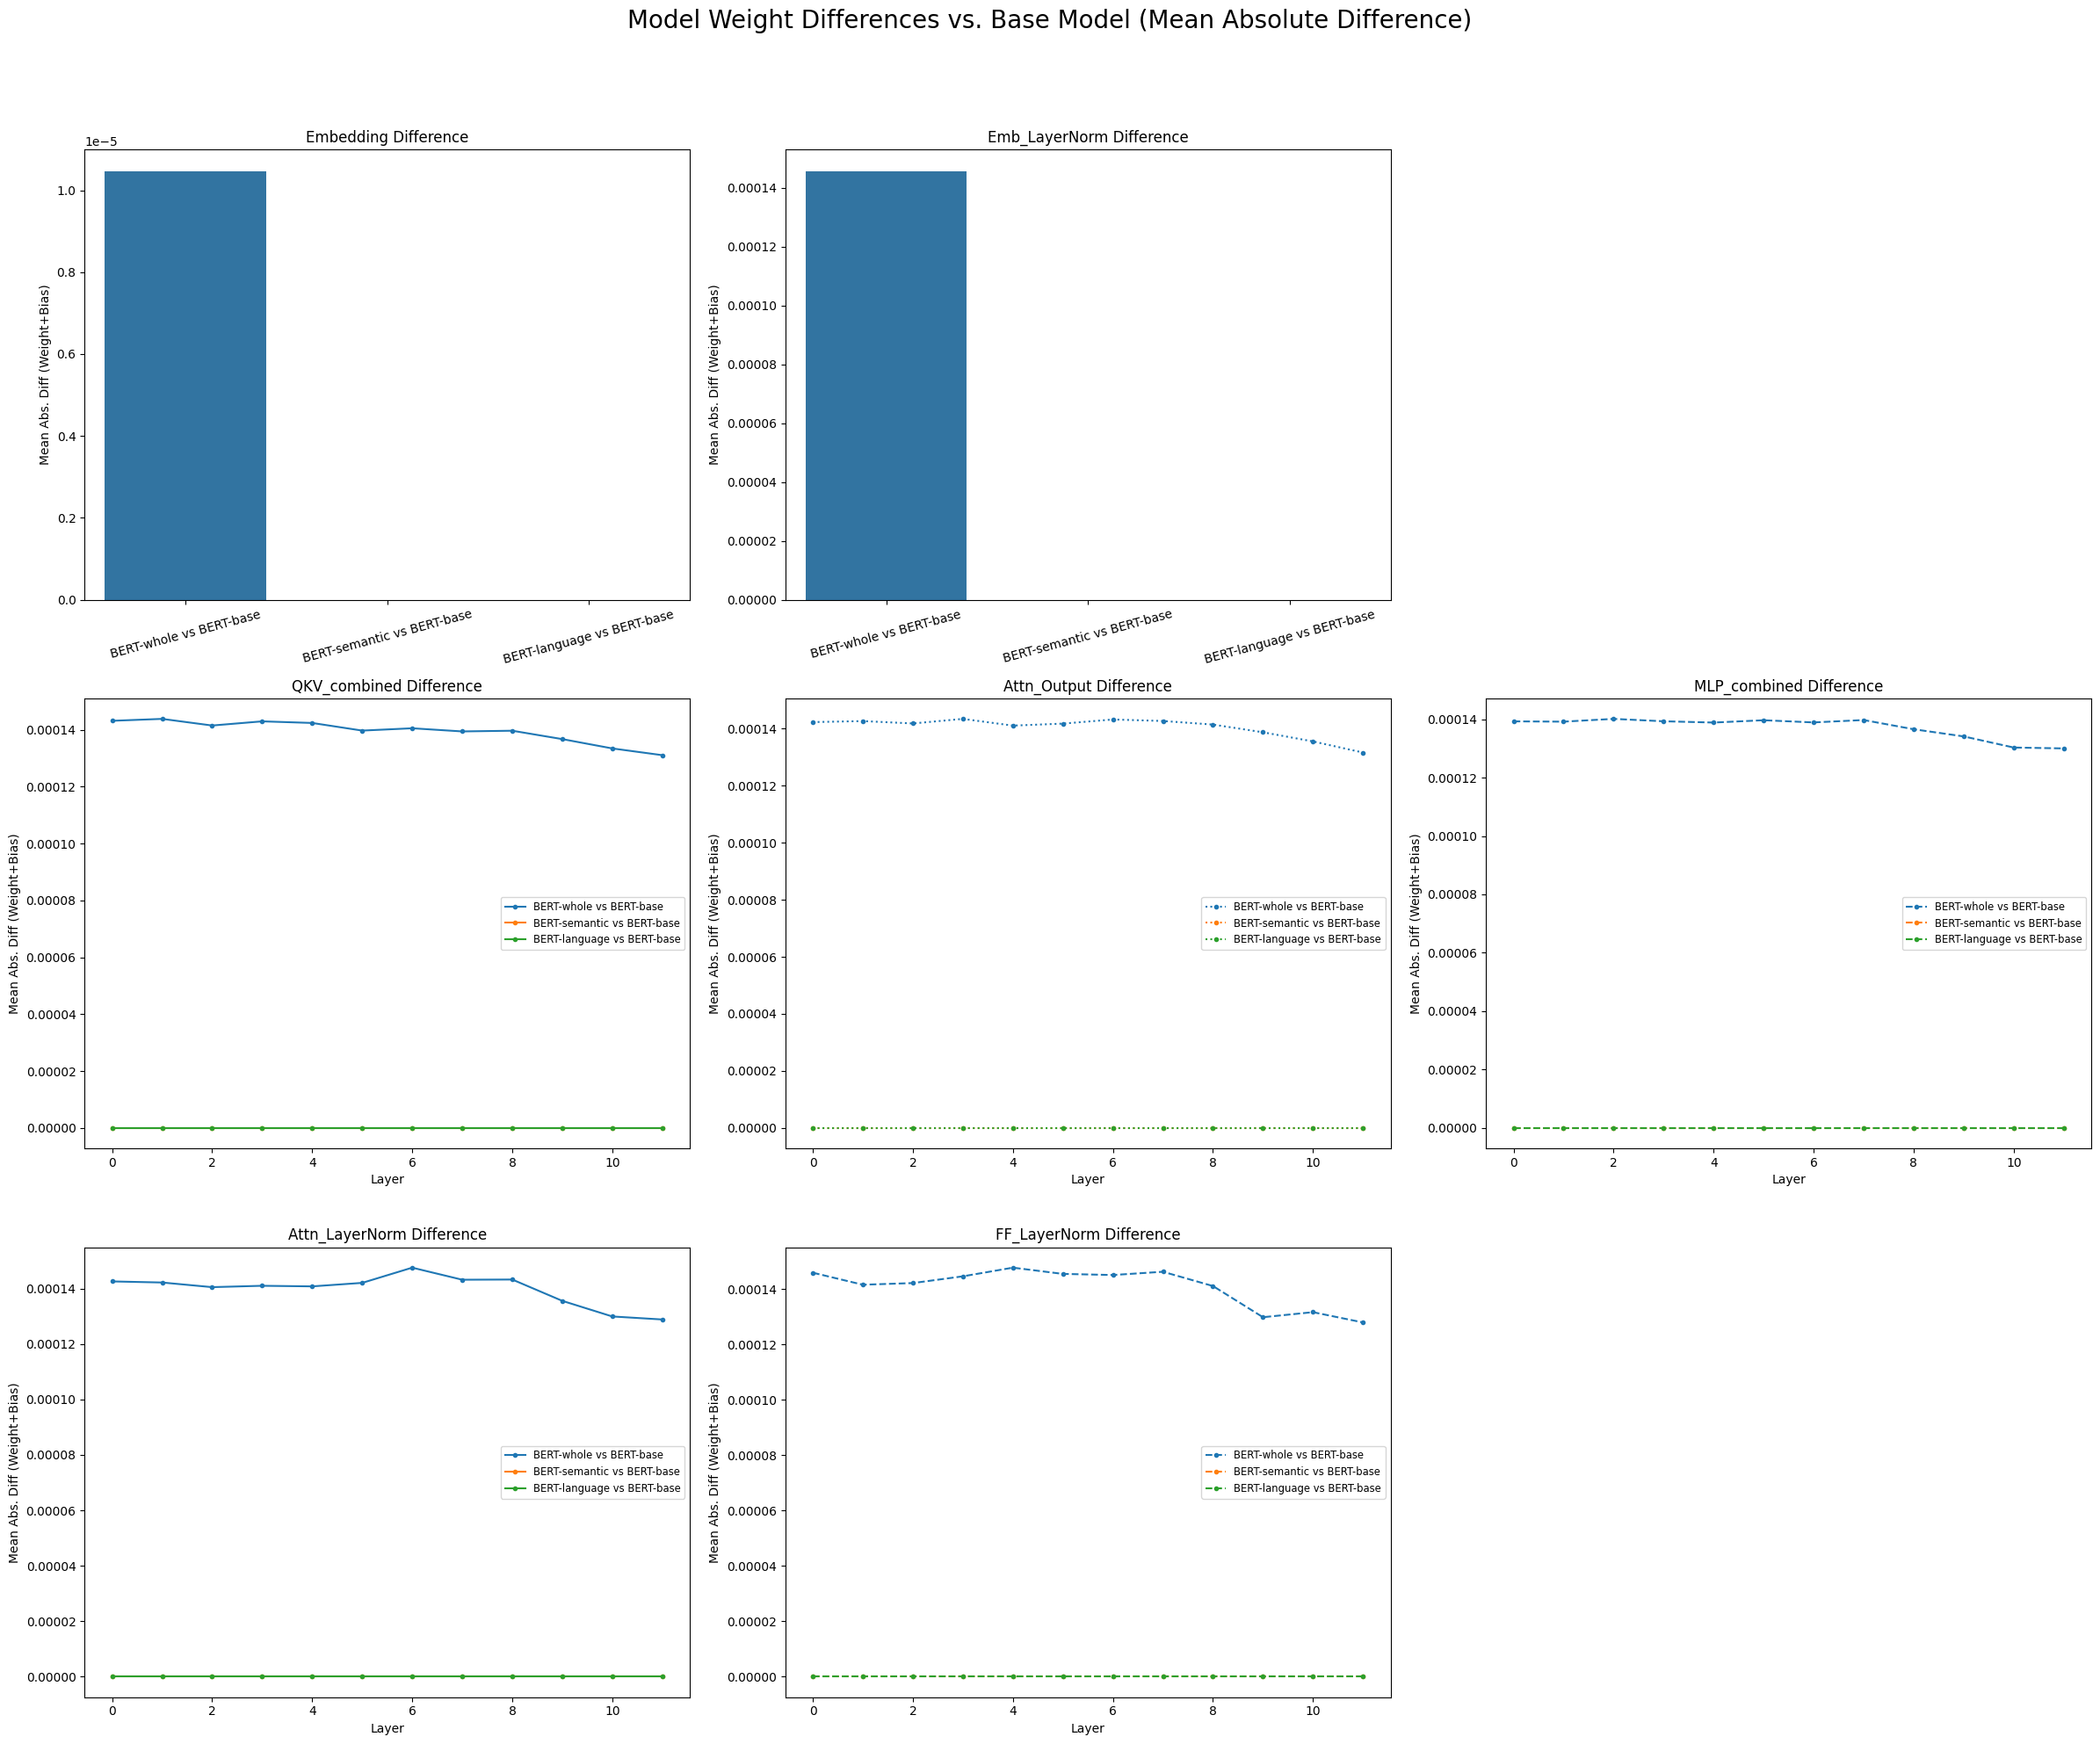

In [6]:
analyzer.plot_weight_analysis_3x3(weight_df) # Call the new 3x3 plot

## Probe Analysis in English 

In [7]:
conllu_train_path = "MASK/Documents/Anuja/UD_English-EWT-master/en_ewt-ud-train.conllu"
conllu_test_path = "MASK/Documents/Anuja/UD_English-EWT-master/en_ewt-ud-test.conllu"

train_sentences = analyzer.read_ud_sentences(conllu_train_path, max_sentences=None)
test_sentences = analyzer.read_ud_sentences(conllu_test_path, max_sentences=None)  # should get me max number of sentences I think?


In [8]:
# For each model, extract representations and run probe
results_list = []
model_names = ["BERT-base", "BERT-whole", "BERT-semantic", "BERT-language"]

for model, tokenizer, name in zip(analyzer.models, analyzer.tokenizers, model_names):
    print(f"Processing {name}...")
    train_layerwise_reps = analyzer.extract_bert_layerwise_reps(train_sentences, model, tokenizer)
    test_layerwise_reps = analyzer.extract_bert_layerwise_reps(test_sentences, model, tokenizer)
    results = analyzer.run_probe(train_layerwise_reps, test_layerwise_reps, max_distance_train=20, max_distance_eval=20)
    results_list.append(results)


Processing BERT-base...


Extracting BERT representations: 100%|██████████| 2077/2077 [00:38<00:00, 54.58it/s]


Processing BERT-whole...


Extracting BERT representations: 100%|██████████| 2077/2077 [00:37<00:00, 55.95it/s]


Processing BERT-semantic...


Extracting BERT representations: 100%|██████████| 2077/2077 [00:38<00:00, 54.47it/s]


Processing BERT-language...


Extracting BERT representations: 100%|██████████| 2077/2077 [00:38<00:00, 54.08it/s]


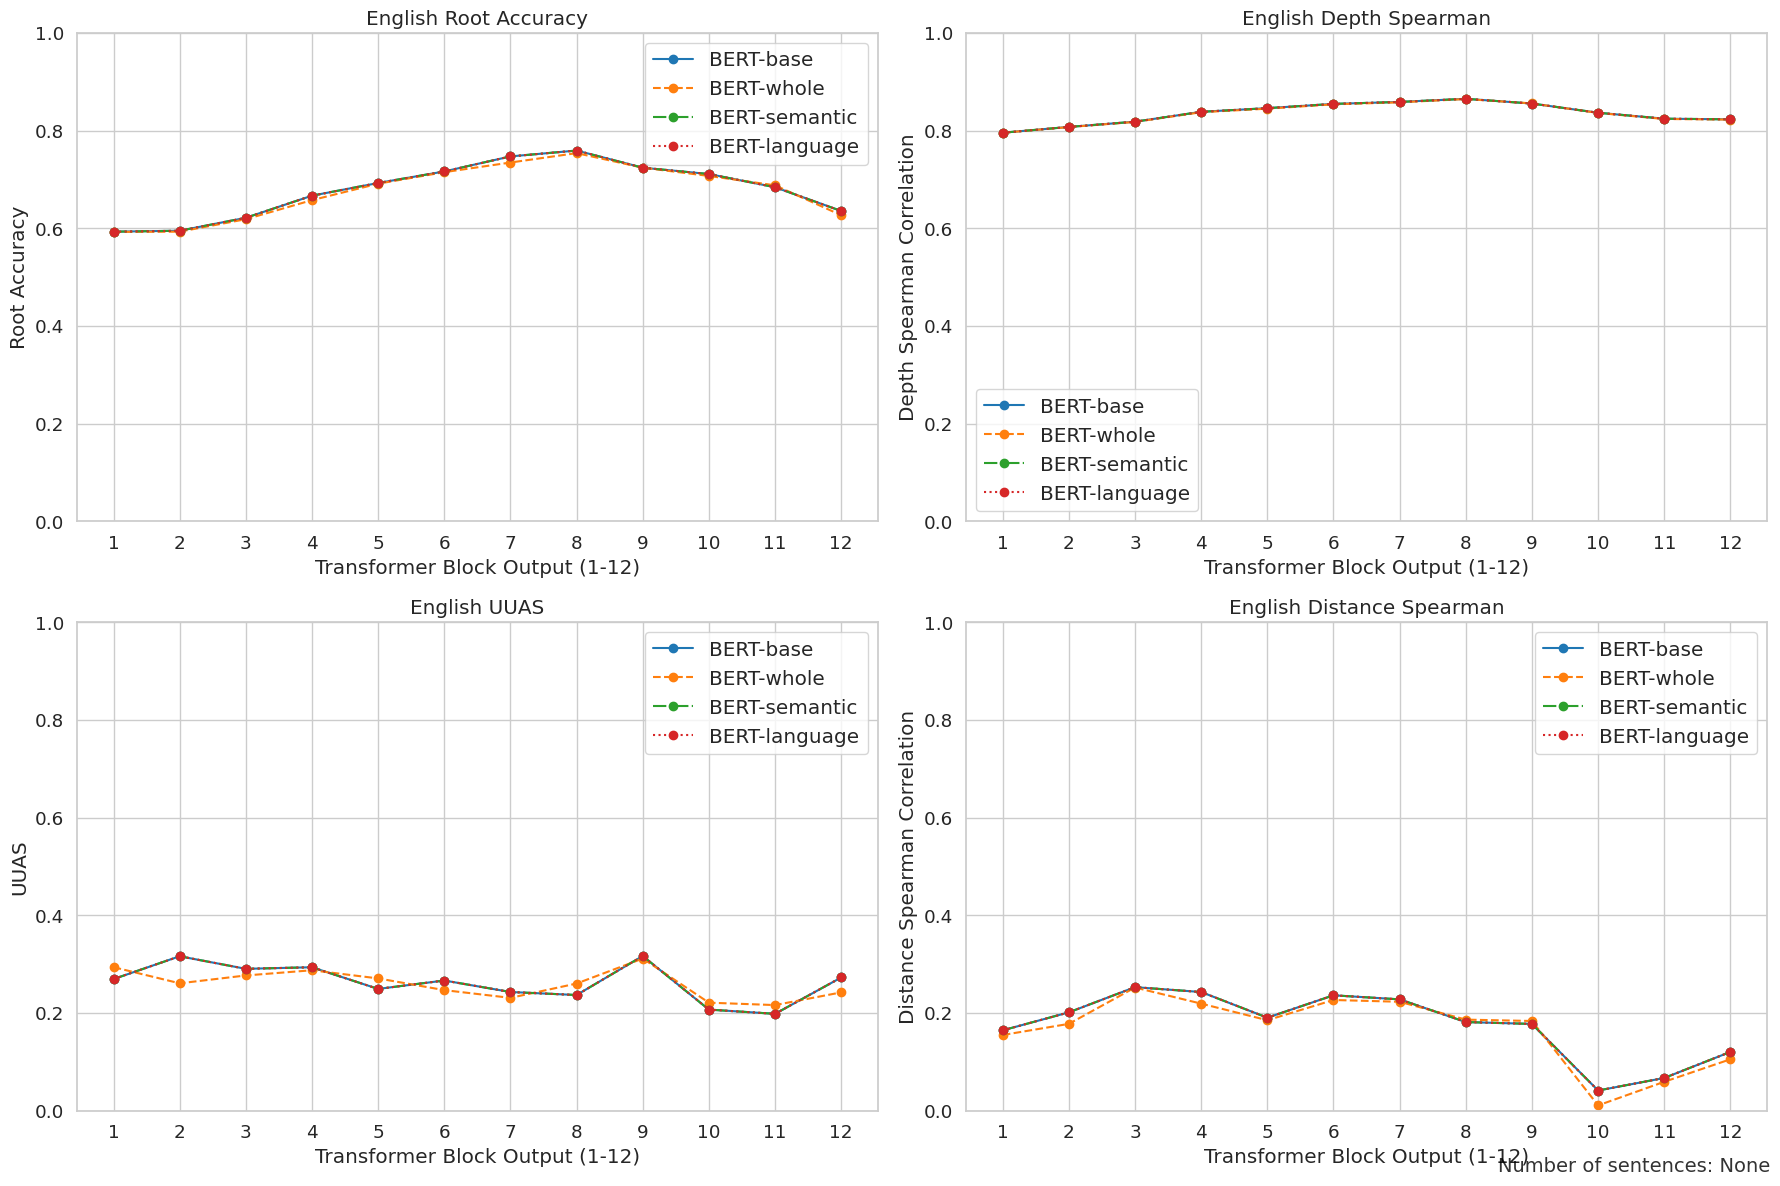

In [9]:
analyzer.plot_probe_results(results_list, model_names=model_names, language="English",y_lowlim=0, max_sentences=None)

Extracting BERT representations: 100%|██████████| 1/1 [00:00<00:00, 34.13it/s]


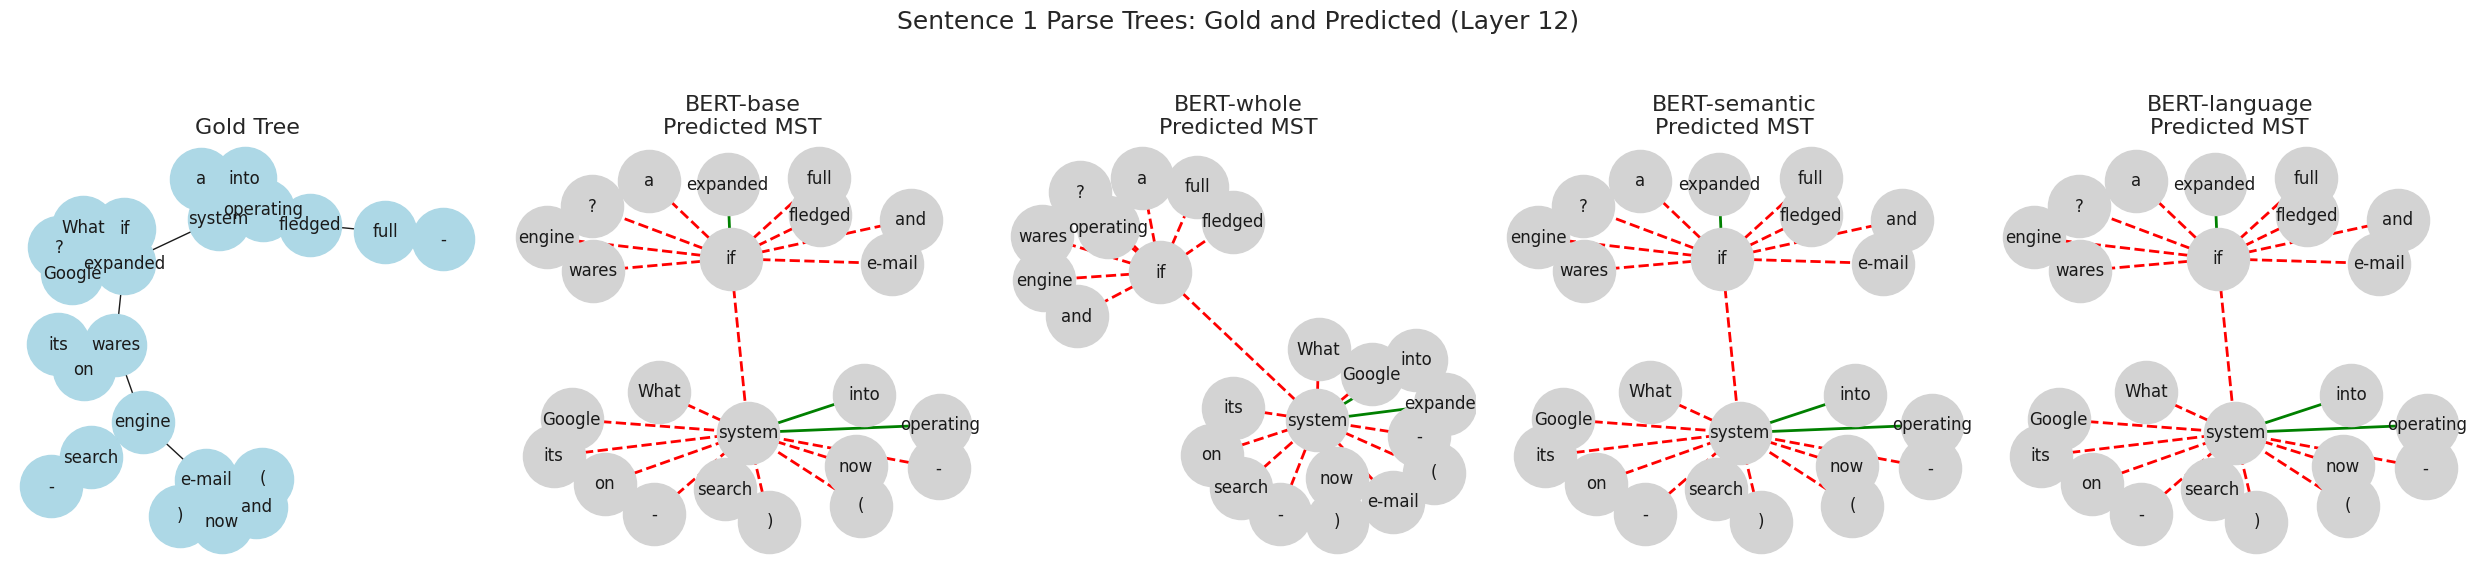

Extracting BERT representations: 100%|██████████| 1/1 [00:00<00:00, 70.19it/s]


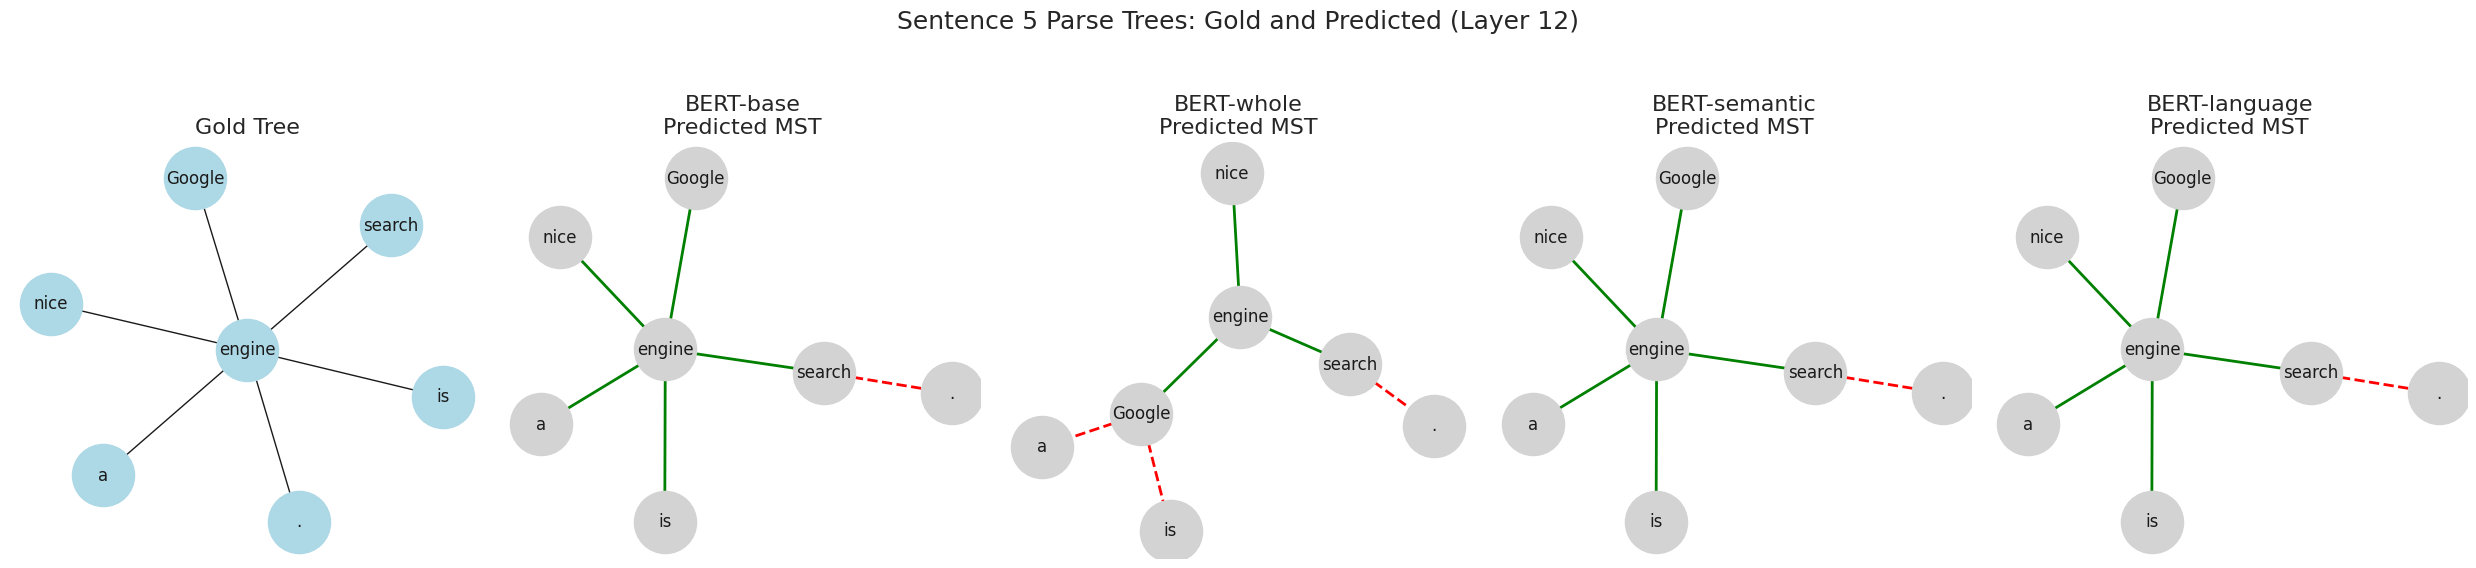

Extracting BERT representations: 100%|██████████| 1/1 [00:00<00:00, 28.19it/s]


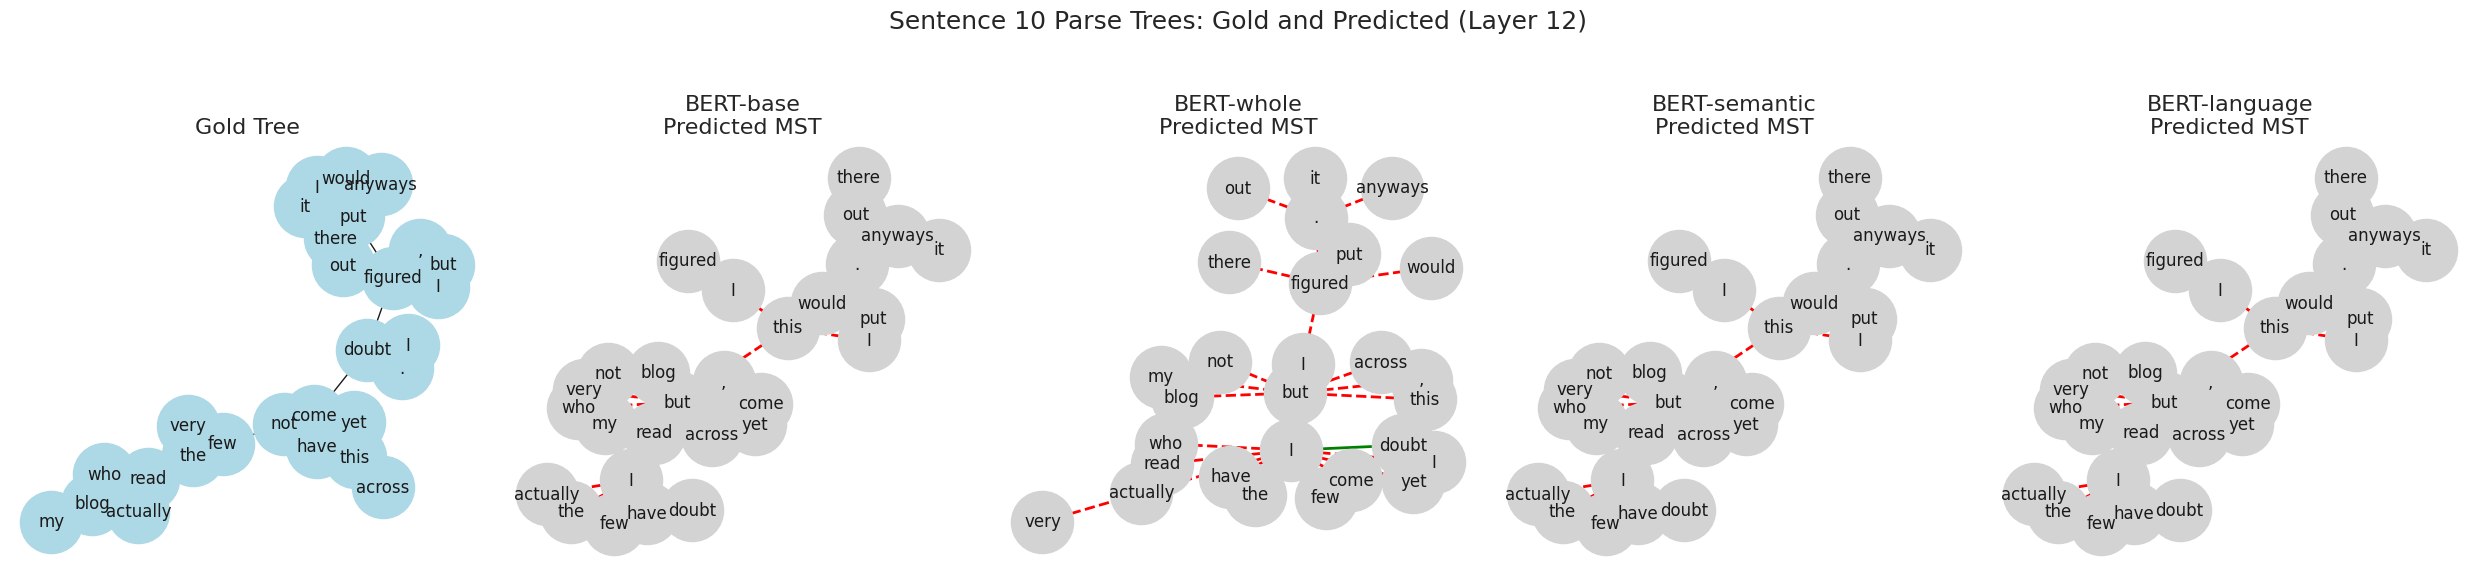

In [10]:
analyzer.plot_gold_and_predicted_trees(test_sentences, results_list, sentence_indices=[1, 5, 10], layer_to_plot=12)

# 2. Probe Analysis - Chinese 

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models
model_language = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh_language.pth", local_files_only=True).to(device)
model_semantic = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh_semantic.pth", local_files_only=True).to(device)
model_whole = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh.pth", local_files_only=True).to(device)
model_base = AutoModel.from_pretrained("bert-base-chinese").to(device)  # Base BERT

# Use the same tokenizer for all (base BERT)
tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese", use_fast=True)


In [12]:
analyzer = StructuralProbeAnalyzer(
    [model_base, model_whole, model_semantic, model_language],
    [tokenizer] * 4,  # same tokenizer for all
    device=device
)


In [13]:
df_compare = analyzer.compare_to_base_attention_embedding_combined(
    model_names=["BERT-base","BERT-whole","BERT-semantic","BERT-language"]
)
df_compare


,Comparison,Layer,Type,Max_Diff,Mean_Diff
0,BERT-whole vs BERT-base,Embedding,Embedding,0.000603,0.000020
1,BERT-whole vs BERT-base,0,QKV_combined,0.000603,0.000244
2,BERT-whole vs BERT-base,1,QKV_combined,0.000601,0.000242
3,BERT-whole vs BERT-base,2,QKV_combined,0.000602,0.000236
4,BERT-whole vs BERT-base,3,QKV_combined,0.000603,0.000241
5,BERT-whole vs BERT-base,4,QKV_combined,0.000602,0.000238
6,BERT-whole vs BERT-base,5,QKV_combined,0.000603,0.000235
7,BERT-whole vs BERT-base,6,QKV_combined,0.000602,0.000230
8,BERT-whole vs BERT-base,7,QKV_combined,0.000603,0.000228
9,BERT-whole vs BERT-base,8,QKV_combined,0.000603,0.000239


In [14]:
weight_df = analyzer.analyze_model_weights(model_names=["BERT-base","BERT-whole","BERT-semantic","BERT-language"])

Base model 'BERT-base' has 12 layers. Base prefix: ''
Analyzing: BERT-whole vs BERT-base


Comparing layers for BERT-whole: 100%|██████████| 12/12 [00:01<00:00,  9.80it/s]


Analyzing: BERT-semantic vs BERT-base


Comparing layers for BERT-semantic: 100%|██████████| 12/12 [00:01<00:00, 10.90it/s]


Analyzing: BERT-language vs BERT-base


Comparing layers for BERT-language: 100%|██████████| 12/12 [00:01<00:00, 11.15it/s]


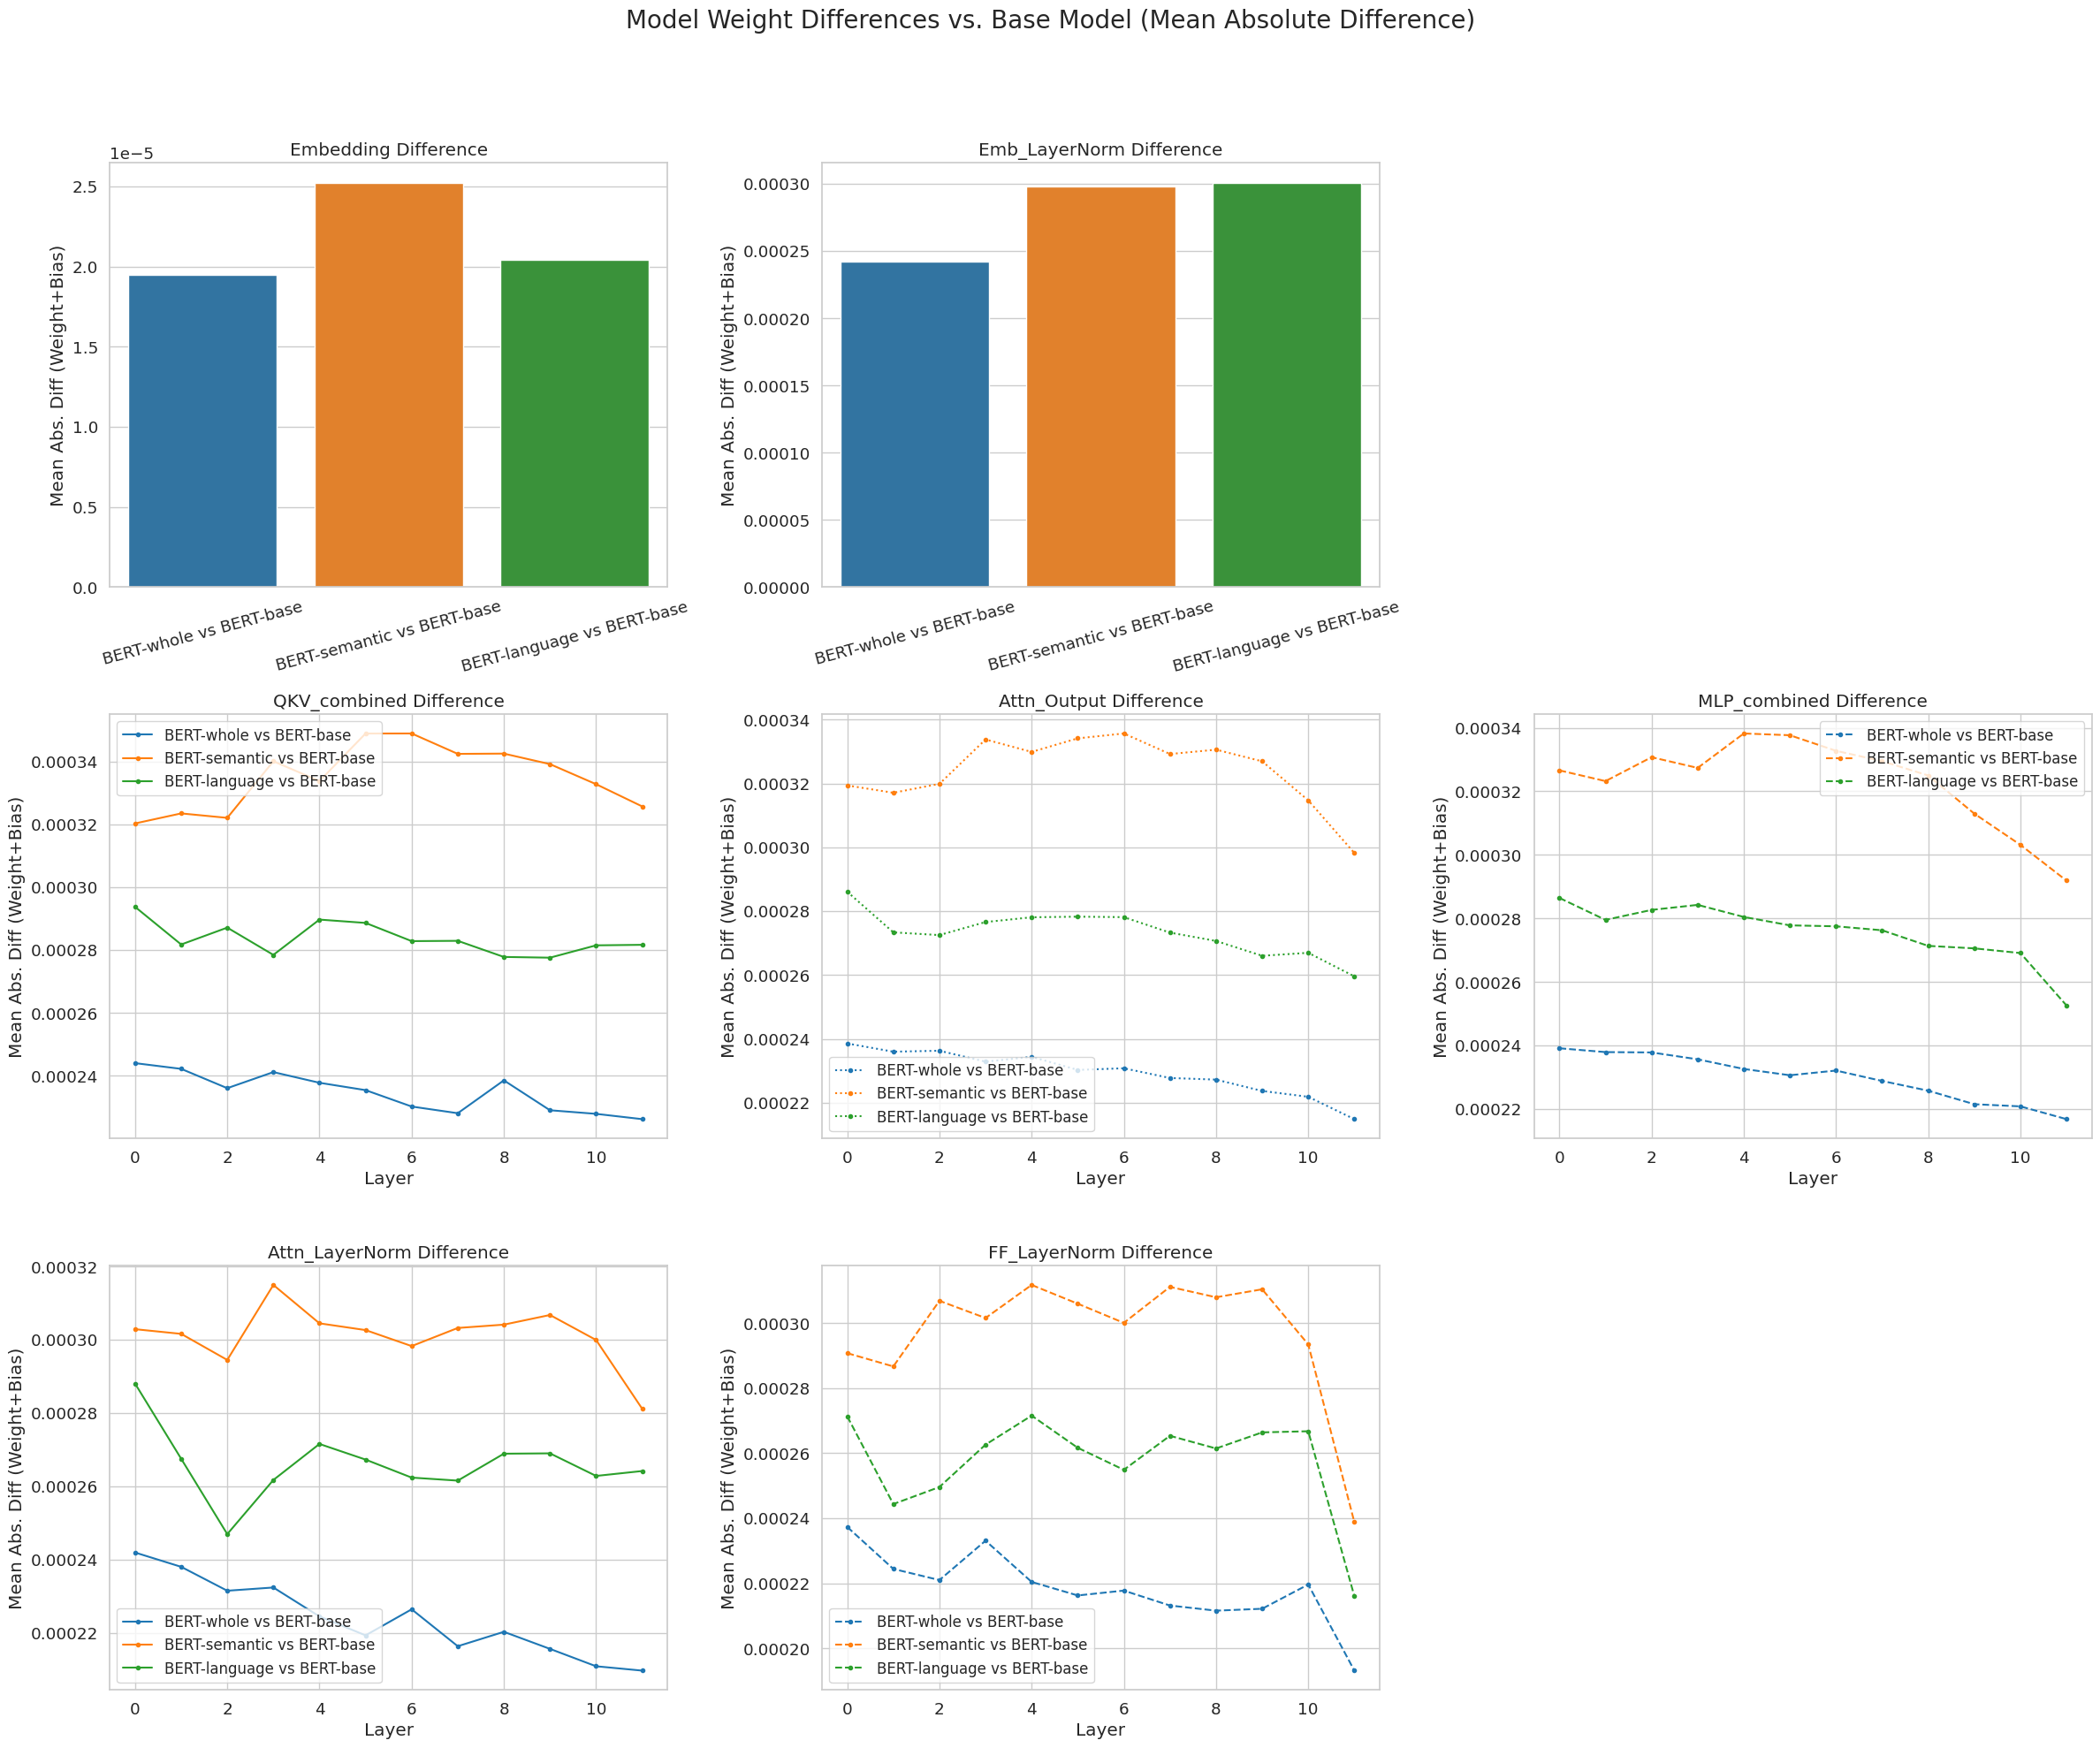

In [15]:
analyzer.plot_weight_analysis_3x3(weight_df) # Call the new 3x3 plot

### Probe Analysis in Chinese (max_sentences=750)

In [16]:
conllu_train_path = "MASK/Documents/Anuja/UD_Chinese-GSD-master/zh_gsd-ud-train.conllu"
conllu_test_path = "MASK/Documents/Anuja/UD_Chinese-GSD-master/zh_gsd-ud-test.conllu"

train_sentences = analyzer.read_ud_sentences(conllu_train_path, max_sentences=None)
test_sentences = analyzer.read_ud_sentences(conllu_test_path, max_sentences=None)  # should get me max number of sentences I think?


In [17]:
# For each model, extract representations and run probe
results_list = []
model_names = ["BERT-base", "BERT-whole", "BERT-semantic", "BERT-language"]

for model, tokenizer, name in zip(analyzer.models, analyzer.tokenizers, model_names):
    print(f"Processing {name}...")
    train_layerwise_reps = analyzer.extract_bert_layerwise_reps(train_sentences, model, tokenizer)
    test_layerwise_reps = analyzer.extract_bert_layerwise_reps(test_sentences, model, tokenizer)
    results = analyzer.run_probe(train_layerwise_reps, test_layerwise_reps, max_distance_train=20, max_distance_eval=20)
    results_list.append(results)


Processing BERT-base...


Extracting BERT representations: 100%|██████████| 500/500 [00:14<00:00, 33.69it/s]


Processing BERT-whole...


Extracting BERT representations: 100%|██████████| 500/500 [00:14<00:00, 34.27it/s]


Processing BERT-semantic...


Extracting BERT representations: 100%|██████████| 500/500 [00:14<00:00, 34.86it/s]


Processing BERT-language...


Extracting BERT representations: 100%|██████████| 500/500 [00:14<00:00, 33.63it/s]


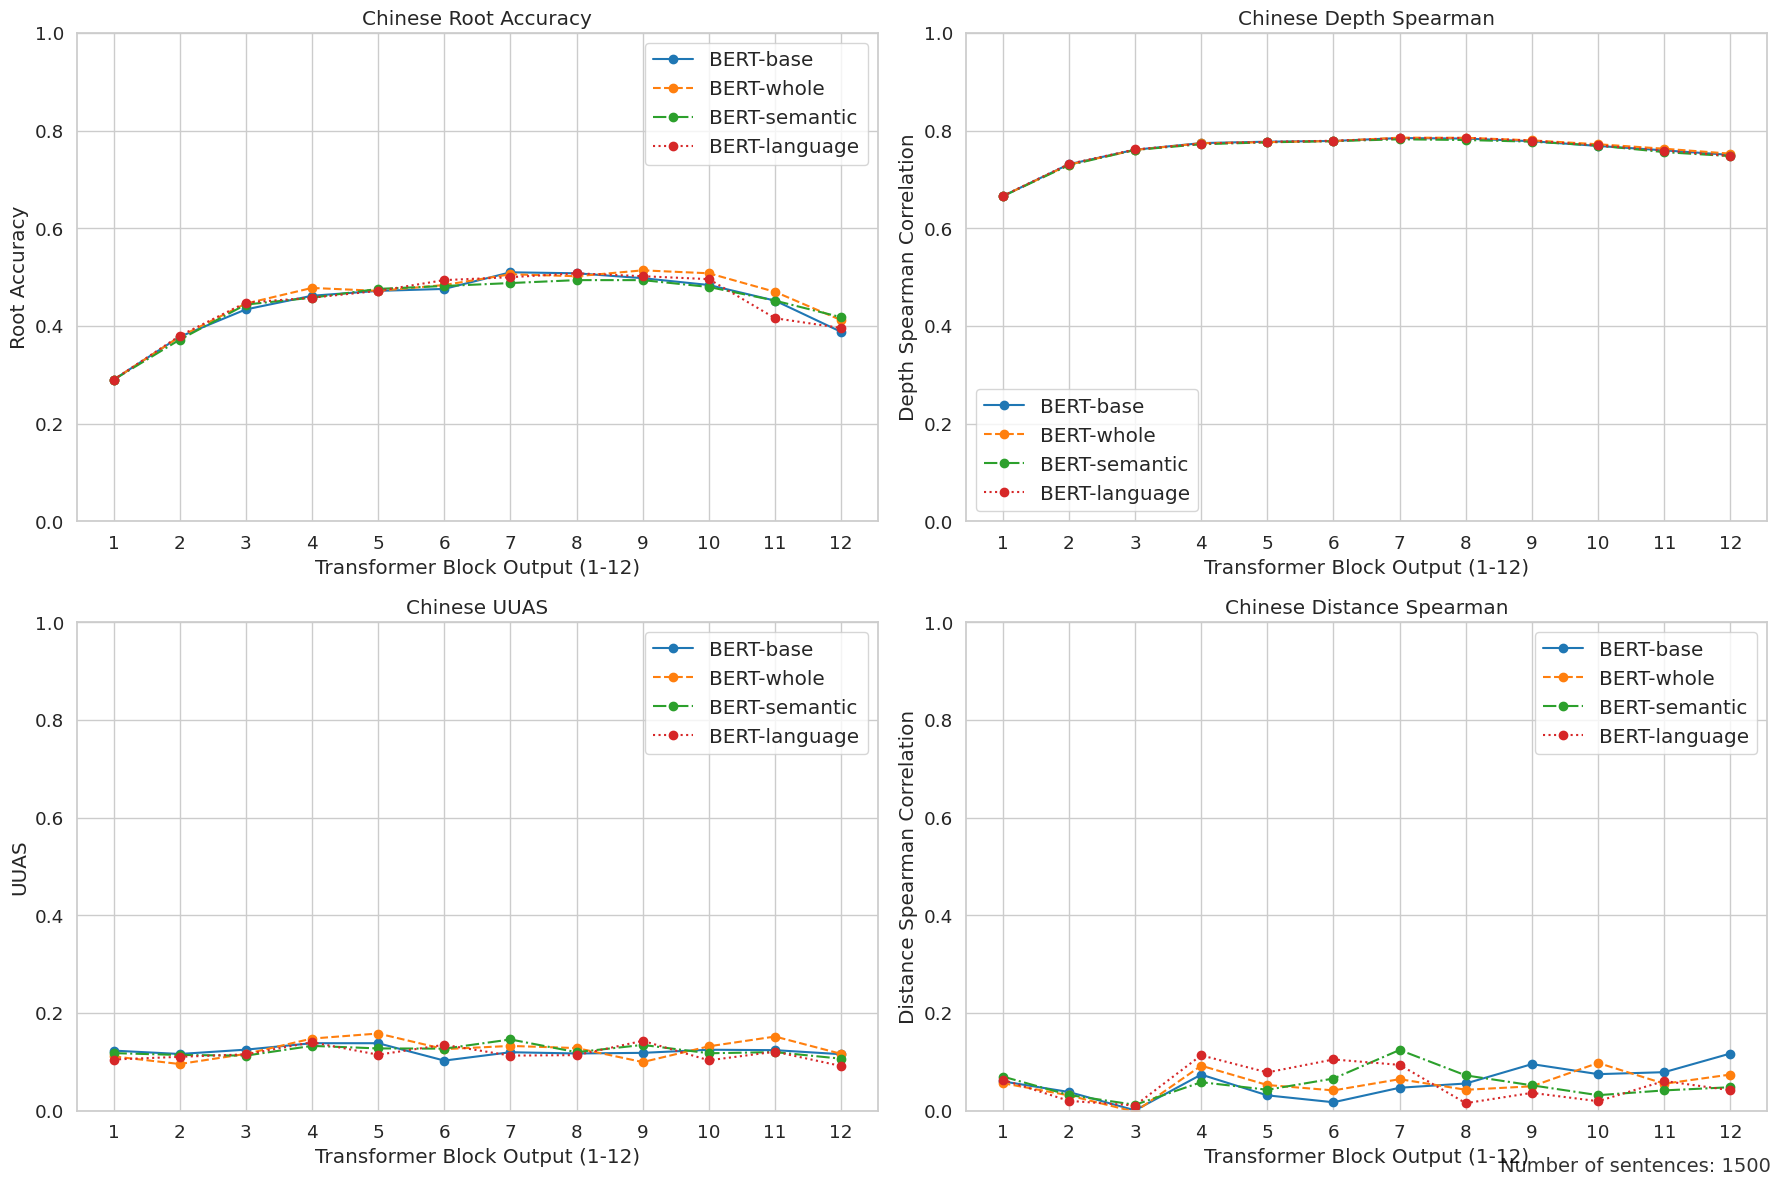

In [18]:
analyzer.plot_probe_results(results_list, model_names=model_names, language="Chinese",y_lowlim=0, max_sentences=1500)

In [27]:
font_path = 'MASK/Documents/Anuja/font/NotoSansMonoCJKsc-Regular.otf'

# Register the font with matplotlib
fontManager.addfont(font_path)

# Get the font name
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()

# Set matplotlib to use this font
plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

Extracting BERT representations: 100%|██████████| 1/1 [00:00<00:00, 37.24it/s]


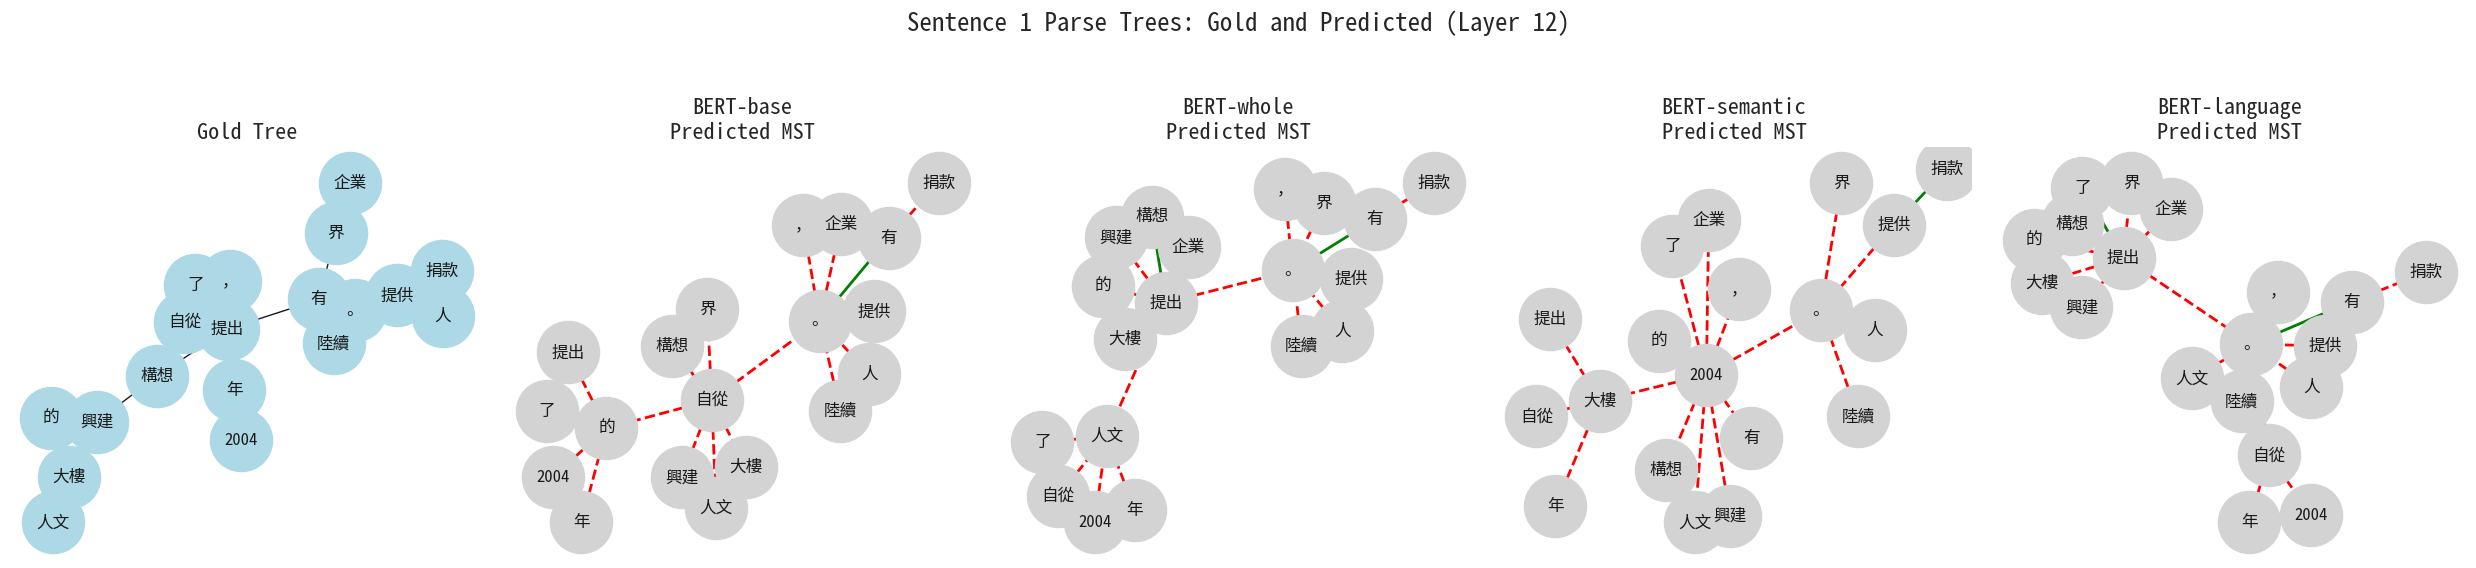

Extracting BERT representations: 100%|██████████| 1/1 [00:00<00:00, 21.28it/s]


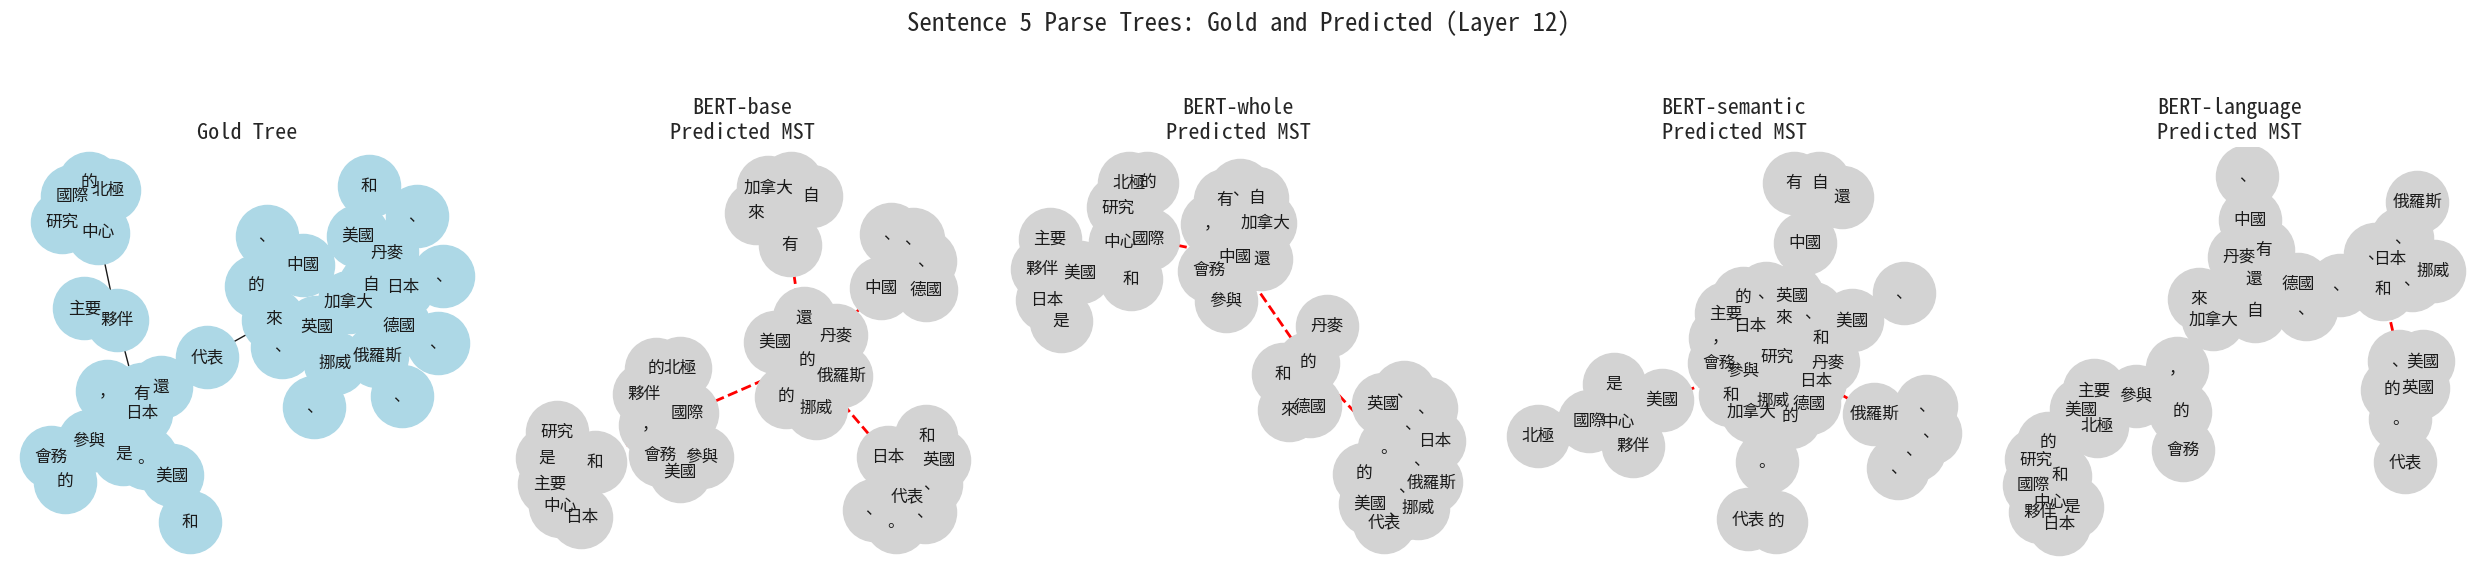

Extracting BERT representations: 100%|██████████| 1/1 [00:00<00:00, 39.03it/s]


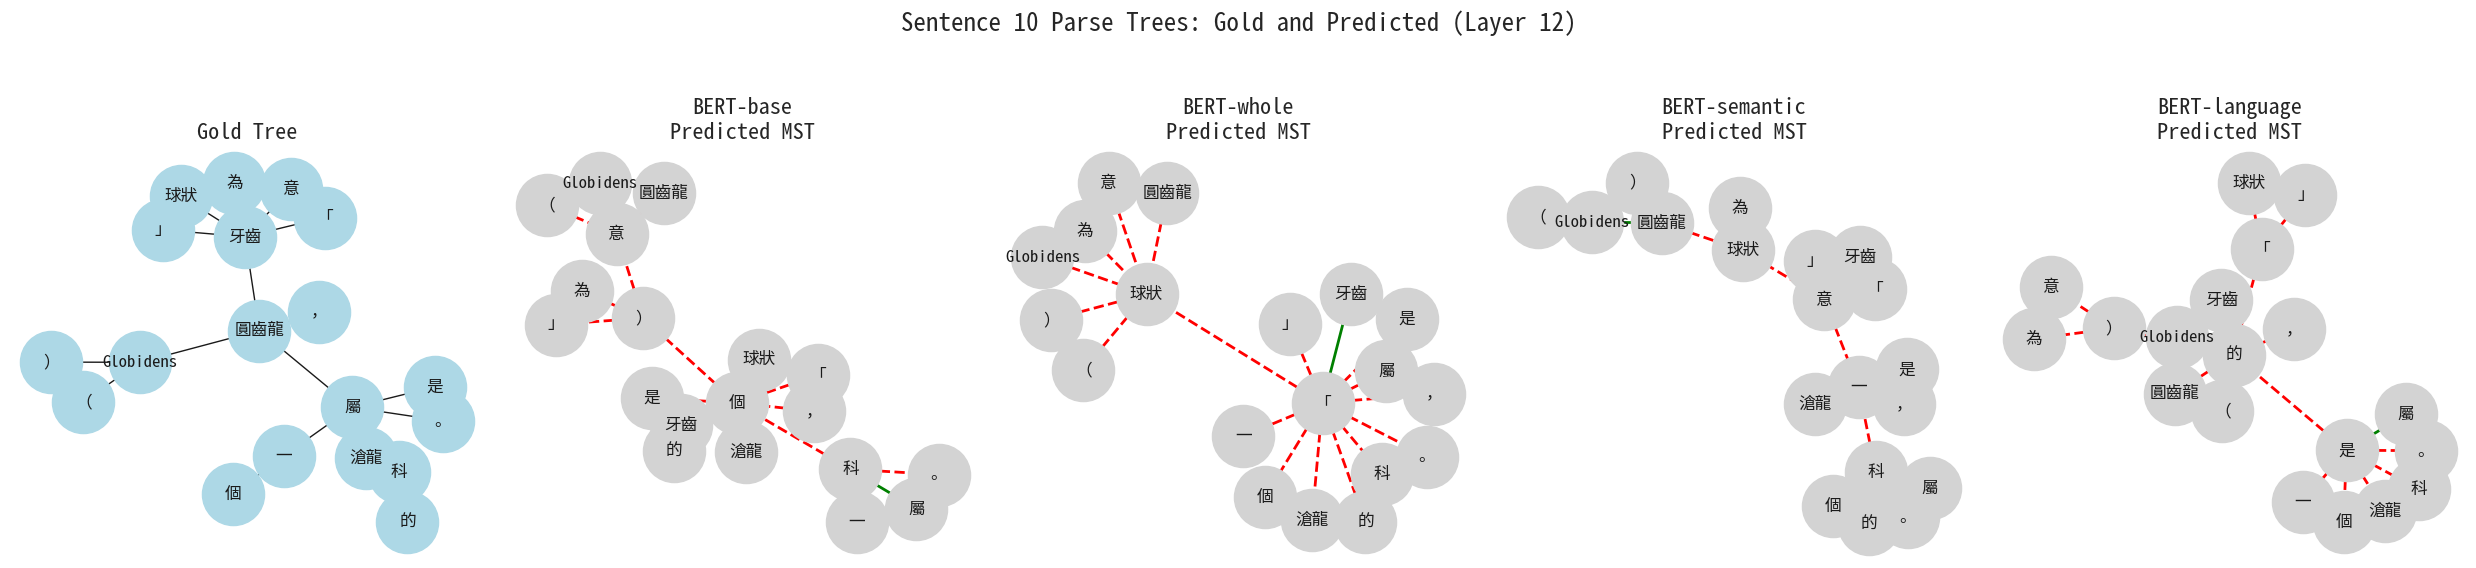

In [28]:
analyzer.plot_gold_and_predicted_trees(test_sentences, results_list, sentence_indices=[1, 5, 10], layer_to_plot=12)

# 3. Representation Analysis - English

In [ ]:
from Rep_Analysis import RSAAnalyzer
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
gith
from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== ENGLISH MODELS =====
model_language_en = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_language.pth", local_files_only=True).to(device)
model_semantic_en = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_semantic.pth", local_files_only=True).to(device)
model_whole_en = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en.pth", local_files_only=True).to(device)
model_base_en = AutoModel.from_pretrained("bert-base-uncased").to(device)

# ===== CHINESE MODELS =====
# Load models
model_language_zh = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh_language.pth", local_files_only=True).to(device)
model_semantic_zh = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh_semantic.pth", local_files_only=True).to(device)
model_whole_zh = AutoModel.from_pretrained("MASK/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh.pth", local_files_only=True).to(device)
model_base_zh = AutoModel.from_pretrained("bert-base-chinese").to(device)  # Base BERT

# Use the same tokenizer for all (base BERT)
tokenizer_zh= AutoTokenizer.from_pretrained("bert-base-chinese", use_fast=True)
tokenizer_en = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

In [3]:
# Initialize RSA Analyzer
rsa = RSAAnalyzer(device)

# ===== LOAD XNLI DATA =====
xnli_data = rsa.load_xnli_parallel(lang1="en", lang2="zh", max_sentences=2000)

## Representation Similarity Analysis - English

In [4]:
xnli_results_en = rsa.compute_rsa_xnli_per_language(
    xnli_data, 
    language="en",
    model_base=model_base_en, 
    model_whole=model_whole_en, 
    model_semantic=model_semantic_en, 
    model_language=model_language_en,
    tokenizer=tokenizer_en
)


Processing premises - contradiction (689 sentences)


Getting hidden states: 100%|██████████| 689/689 [00:05<00:00, 125.49it/s]



Processing premises - neutral (573 sentences)


Getting hidden states: 100%|██████████| 573/573 [00:04<00:00, 126.45it/s]



Processing premises - entailment (738 sentences)


...

Getting hidden states: 100%|██████████| 689/689 [00:05<00:00, 127.47it/s]



Processing hypotheses - neutral (573 sentences)


Getting hidden states: 100%|██████████| 573/573 [00:04<00:00, 126.29it/s]



Processing hypotheses - entailment (738 sentences)


Getting hidden states: 100%|██████████| 738/738 [00:05<00:00, 126.31it/s]


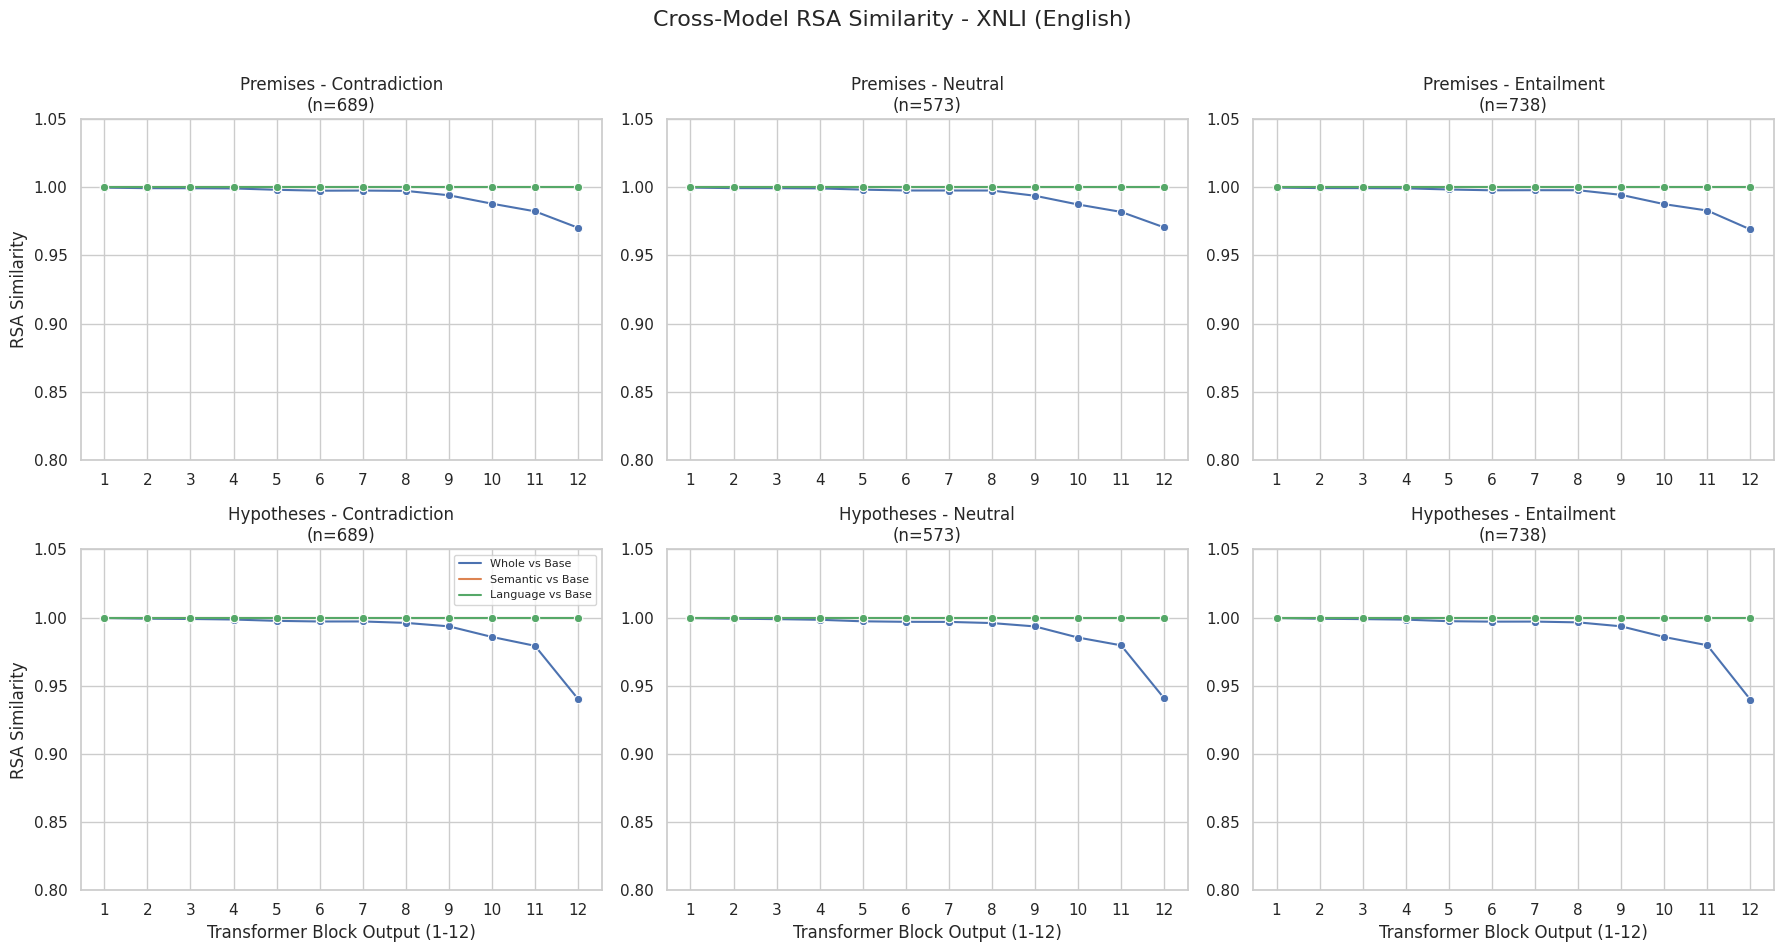

In [11]:
rsa.plot_rsa_xnli(xnli_results_en, language="English", y_limlow=0.8, y_limup=1.05)

## Representation Similarity Analysis - Chinese

In [12]:
xnli_results_zh = rsa.compute_rsa_xnli_per_language(
    xnli_data, 
    language="zh",
    model_base=model_base_zh, 
    model_whole=model_whole_zh, 
    model_semantic=model_semantic_zh, 
    model_language=model_language_zh,
    tokenizer=tokenizer_zh
)


Processing premises - contradiction (689 sentences)


Getting hidden states: 100%|██████████| 689/689 [00:05<00:00, 126.71it/s]



Processing premises - neutral (573 sentences)


Getting hidden states: 100%|██████████| 573/573 [00:04<00:00, 122.26it/s]



Processing premises - entailment (738 sentences)


...

Getting hidden states: 100%|██████████| 689/689 [00:05<00:00, 126.38it/s]



Processing hypotheses - neutral (573 sentences)


Getting hidden states: 100%|██████████| 573/573 [00:04<00:00, 124.56it/s]



Processing hypotheses - entailment (738 sentences)


Getting hidden states: 100%|██████████| 738/738 [00:05<00:00, 125.20it/s]


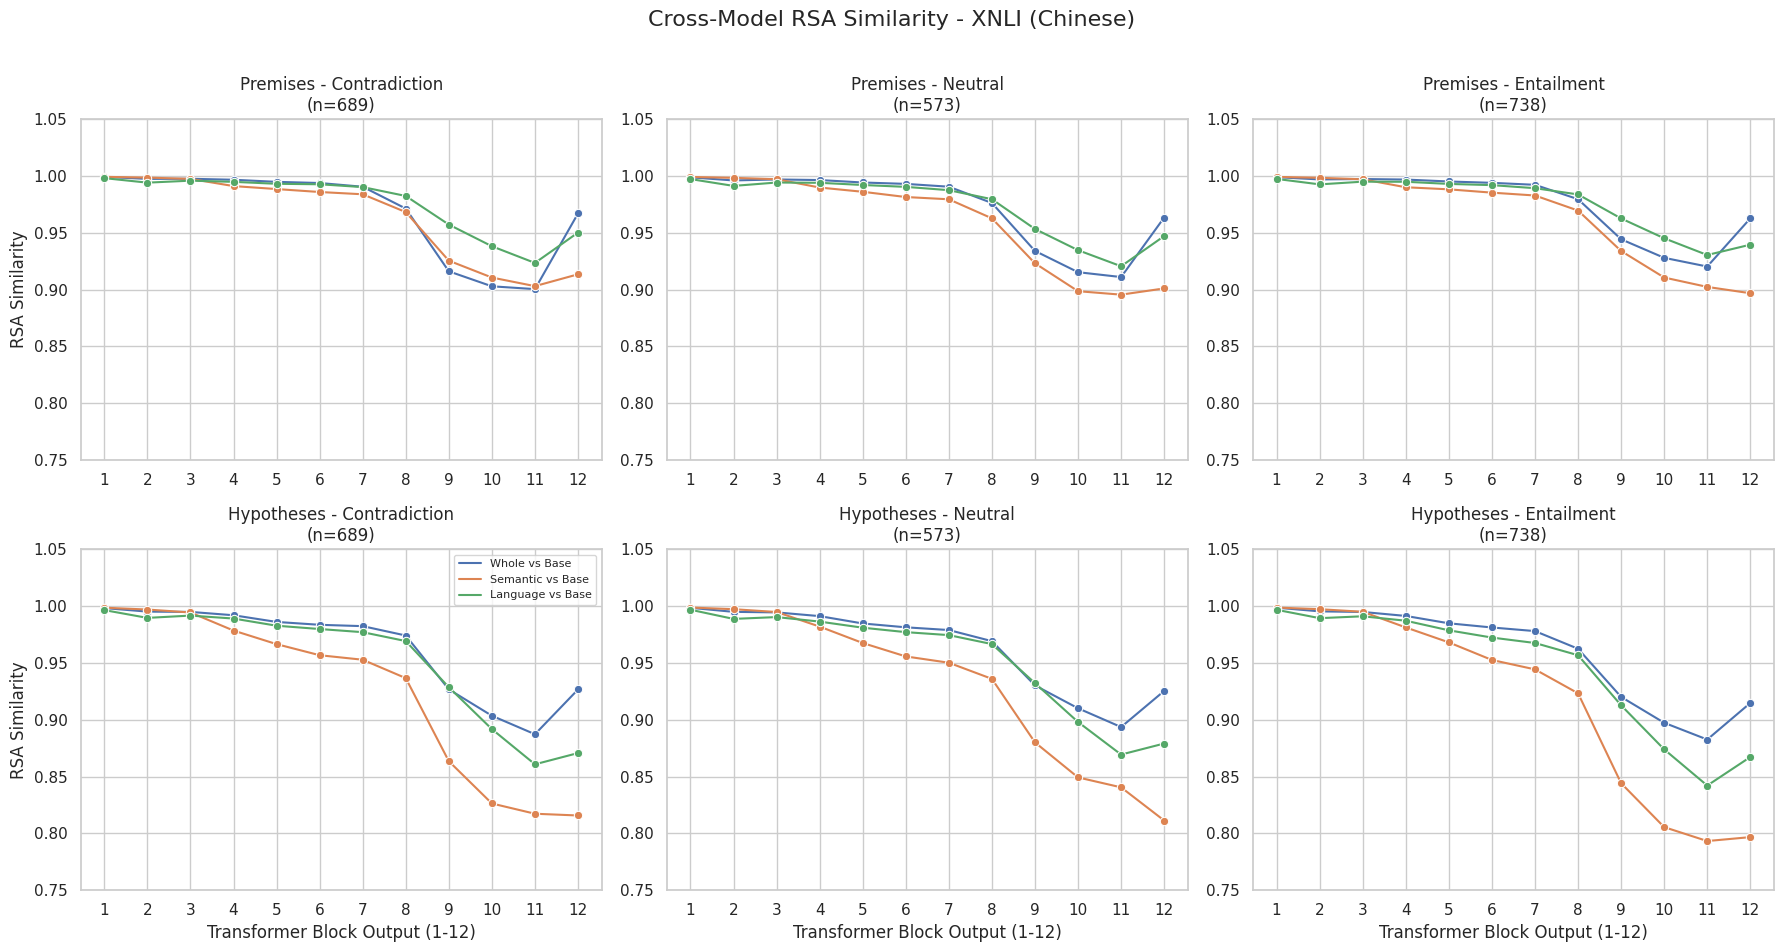

In [14]:
rsa.plot_rsa_xnli(xnli_results_zh, language="Chinese", y_limlow=0.75, y_limup=1.05)